# R13 transport - records: H132 WMD token bags, H133 Sinkhorn spec residual, H137 barycenter chain guard

**Author**: Knowledge Graph Foundry autonomous build (kj) <br>
**Date**: 2026-07-07 <br>
**Pipeline stage**: R13 optimal-transport round, CPU-now batch (token embedder on GPU 2) <br>
**Graph**: rebuilt CPAP graph (neo4j2, read-only) <br>

Three optimal-transport tests over the record content itself - the token bag and the spec set.

**H132** - Word Mover's Distance over record token bags (name + type + spec-key tokens). Cosine
collapses "Pro-Flow adult nasal cannula" to one vector; WMD transports token embeddings and pays
explicitly for the token with no counterpart. Bar: WMD AUC (duplicate vs sibling) >= raw Titan
cosine AUC + 0.10. Refuter: token embeddings equally anisotropic (couple with H131 whitening).

**H133** - Sinkhorn over the key-value spec sets. The sibling problem is structured disagreement:
most spec keys match, one value differs. OT yields matched mass AND unmatched / expensive residual
mass as separate quantities. Bar: residual flags siblings at >= 0.8 precision where both records
carry >= 3 spec items. Refuter: spec-value embeddings too coarse to localize the disagreement.

**H137** - Wasserstein barycenter of a SAME_AS cluster's member record-bags; member-to-barycenter
distance should sit far for the false-chained members (the model_code / deictic intruders). Bar:
distance separates false from true members at AUC >= 0.85 and thresholds them out with zero
true-member loss. Refuter: barycenters of small clusters too unstable to threshold.

## Outputs
- H132: WMD-vs-cosine AUC gap on the dup-vs-sibling task, whitened-token variant
- H133: residual precision on the sibling set, combined-feature AUC
- H137: member-to-barycenter distance AUC + threshold sweep on the false closures
- report JSON to ../reports/transport-r13-records-<UTC>.json

In [1]:
# GPU selection - MUST precede torch / sentence-transformers import (GPU 2 only, GPUs 0/1 reserved)
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
# Imports
# stdlib
import datetime  # report stamps
import json  # report + inventory
import glob  # latest pair set / forensics report
import re  # tokenization
from pathlib import Path
from collections import Counter, defaultdict

# third party
import numpy as np  # transforms
import ot  # POT - EMD, Sinkhorn, free-support barycenter
import torch  # device check
from sentence_transformers import SentenceTransformer  # token / string embedder
from sklearn.linear_model import LogisticRegression  # H133 combined feature
from sklearn.model_selection import cross_val_predict  # honest CV AUC
from sklearn.metrics import roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt
from rich import print as rprint
from neo4j import GraphDatabase

np.random.seed(42)

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Configuration
NEO4J_URI = "bolt://user-konrad.jelen-kgf-neo4j2:7687"  # read-only graph
EMB_MODEL = "BAAI/bge-m3"          # cached locally, 1024-d, bge family (bge-base-en not cached)
SINKHORN_REG = 0.05                # H133 entropic regularization
RESID_COST_THR = 0.30              # H133: a spec item is unmatched if transported at cost > this (1-cos)
DUP_CLASSES = ("variance", "resolver_miss", "samename")  # y=1 duplicates
SIB_CLASSES = ("sibling",)         # hard negatives - differing model token
BAR_H132_GAP = 0.10                # WMD AUC must beat raw cosine AUC by this
BAR_H133_PREC = 0.80               # residual precision on the sibling set
BAR_H137_AUC = 0.85                # member-to-barycenter separation

STOP = set("a an the of for and or to with in on at by from is are as this that".split())

_line = "─" * 46
rprint(f"[bold cyan]Configuration[/bold cyan]\n[dim]{_line}[/dim]")
rprint(f"  Graph      : [cyan]{NEO4J_URI}[/cyan] [dim](read-only)[/dim]")
rprint(f"  Embedder   : [cyan]{EMB_MODEL}[/cyan] on GPU 2")
rprint(f"  Cost       : [yellow]1 - cosine[/yellow]   Sinkhorn reg [yellow]{SINKHORN_REG}[/yellow]   residual thr [yellow]{RESID_COST_THR}[/yellow]")
rprint(f"  Bars       : H132 gap >= [yellow]{BAR_H132_GAP}[/yellow]  H133 precision >= [yellow]{BAR_H133_PREC}[/yellow]  H137 AUC >= [yellow]{BAR_H137_AUC}[/yellow]")

Configuration
──────────────────────────────────────────────

Graph      : bolt://user-konrad.jelen-kgf-neo4j2:7687 (read-only)

Embedder   : BAAI/bge-m3 on GPU 2

Cost       : 1 - cosine   Sinkhorn reg 0.05   residual thr 0.3

Bars       : H132 gap >= 0.1  H133 precision >= 0.8  H137 AUC >= 0.85

## Data loading

Entities (name, type labels, Titan embedding, prop_* spec map) and SAME_AS edges (method,
evidence) from neo4j2. The labeled pair set is the R12 foundation report; the labeled false
merges come from the R11 identity-forensics report.

In [4]:
driver = GraphDatabase.driver(NEO4J_URI, auth=("neo4j", "kgfoundry"),
                              notifications_min_severity="OFF")
with driver.session() as s:
    rows = s.run(
        "MATCH (e:Entity) WHERE e.embedding IS NOT NULL "
        "RETURN e.name AS name, [l IN labels(e) WHERE l <> 'Entity'] AS types, "
        "properties(e) AS p"
    ).data()
    same_as = s.run(
        "MATCH (a:Entity)-[r:SAME_AS]-(b:Entity) "
        "RETURN a.name AS a, b.name AS b, r.method AS m, r.evidence AS ev"
    ).data()
driver.close()

E = {}  # name -> {types, emb (unit np), spec {prop_k: v}}
for r in rows:
    if r["name"] in E:
        continue
    p = dict(r["p"])
    emb = np.asarray(p.pop("embedding"), dtype=np.float32)
    emb = emb / (np.linalg.norm(emb) + 1e-9)
    spec = {k: v for k, v in p.items() if k.startswith("prop_")}
    E[r["name"]] = {"types": r["types"], "emb": emb, "spec": spec}

pair_file = sorted(glob.glob("../reports/matching-r12-foundation-*.json"))[-1]
pairs = json.load(open(pair_file))["pairs"]
forensics_file = sorted(glob.glob("../reports/identity-forensics-r11-final-*.json"))[-1]
forensics = json.load(open(forensics_file))
labeled_fm = forensics["labeled_false_merges"]

rprint(f"entities [yellow]{len(E)}[/yellow]  SAME_AS edges [yellow]{len(same_as)}[/yellow]  "
       f"pair set [yellow]{len(pairs)}[/yellow] from [dim]{Path(pair_file).name}[/dim]")
rprint(f"labeled false merges [yellow]{len(labeled_fm)}[/yellow] from [dim]{Path(forensics_file).name}[/dim]")
rprint("pair classes:", dict(Counter(p["cls"] for p in pairs)))

entities 2797  SAME_AS edges 254  pair set 252 from matching-r12-foundation-20260706-211008.json

labeled false merges 6 from identity-forensics-r11-final-20260706-205147.json

pair classes:
{'variance': 47, 'resolver_miss': 19, 'samename': 20, 'false_merge': 6, 'sibling': 40, 'random': 120}

In [5]:
# Token embedder on GPU 2, with a per-string cache
model = SentenceTransformer(EMB_MODEL, device="cuda")
print("embedder device:", model.device, "dim", model.get_embedding_dimension())

_emb_cache = {}
def embed_strings(strings):
    "Embed a list of strings (normalized), caching per unique string."
    todo = sorted({x for x in strings if x not in _emb_cache})
    if todo:
        vecs = model.encode(todo, normalize_embeddings=True, batch_size=256,
                            show_progress_bar=False)
        for x, v in zip(todo, vecs):
            _emb_cache[x] = np.asarray(v, dtype=np.float32)
    return {x: _emb_cache[x] for x in strings}

def tokens_of(name):
    "Token bag: name + type labels + spec-KEY names, stopword-stripped, deduped."
    ent = E[name]
    toks = re.findall(r"[a-z0-9]+", (name or "").casefold())
    for t in ent["types"]:
        toks += re.findall(r"[a-z0-9]+", t.casefold())
    for k in ent["spec"]:
        toks += re.findall(r"[a-z0-9]+", k[len("prop_"):].casefold())
    toks = [t for t in toks if t not in STOP and len(t) > 1]
    return list(dict.fromkeys(toks))

def spec_items(name):
    "Key-value spec items as 'key value' strings."
    out = []
    for k, v in E[name]["spec"].items():
        out.append(f"{k[len('prop_'):].replace('_', ' ')} {v}")
    return out

def cos_titan(a, b):
    return float(E[a]["emb"] @ E[b]["emb"])

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 9955.16it/s]

embedder device: cuda:0 dim 1024


## H132 - Word Mover's Distance over token bags

WMD is the exact EMD between two token bags (uniform weights) with cost `1 - cosine` on bge token
embeddings. The task is the decision band that matters: duplicates (variance / resolver_miss /
samename) vs siblings (differing model token). Baseline is the raw Titan entity cosine on the same
pairs. The whitened-token variant fits centering + PCA-whitening on all token embeddings and
recomputes WMD - the registered H131 interaction (is token-level transport also saturated?).

task pairs 126  unique tokens 536


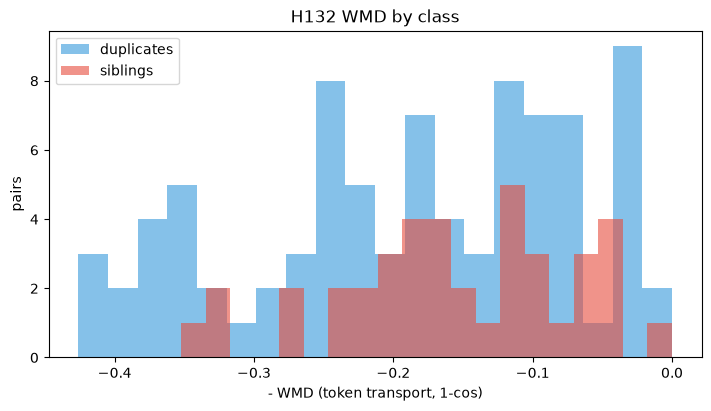

H132 - WMD vs raw cosine
──────────────────────────────────────────────

task pairs scored : 126 (86 dup / 40 sib)

raw Titan cosine  : 0.877

WMD (1-cos)       : 0.431   gap -0.447  (bar +0.1)

WMD (whitened)    : 0.429

verdict : REFUTED

In [6]:
# Build the dup-vs-sibling task and pre-embed every token in it
task = [(p["a"], p["b"], 1 if p["cls"] in DUP_CLASSES else 0)
        for p in pairs if p["cls"] in DUP_CLASSES + SIB_CLASSES
        and p["a"] in E and p["b"] in E]

all_tokens = set()
for a, b, y in task:
    all_tokens.update(tokens_of(a)); all_tokens.update(tokens_of(b))
tok_emb = embed_strings(sorted(all_tokens))
print(f"task pairs {len(task)}  unique tokens {len(tok_emb)}")

# whitening fit on all task-token embeddings (H131 interaction)
T = np.stack([tok_emb[t] for t in sorted(tok_emb)])
mu_t = T.mean(0)
U, S, Vt = np.linalg.svd(T - mu_t, full_matrices=False)
W = Vt.T / (S + 1e-6) * np.sqrt(len(T))
tok_emb_w = {t: (v - mu_t) @ W for t, v in tok_emb.items()}

def wmd(a, b, emb, unit):
    ta, tb = tokens_of(a), tokens_of(b)
    if not ta or not tb:
        return None
    Va = np.stack([emb[t] for t in ta]); Vb = np.stack([emb[t] for t in tb])
    if unit:
        M = 1.0 - Va @ Vb.T                          # 1 - cosine
    else:
        M = ot.dist(Va, Vb, metric="sqeuclidean")    # whitened -> sq-euclidean
    wa = np.full(len(ta), 1.0 / len(ta)); wb = np.full(len(tb), 1.0 / len(tb))
    return float(ot.emd2(wa, wb, np.ascontiguousarray(M)))

ys, s_wmd, s_wmdw, s_cos = [], [], [], []
for a, b, y in task:
    d = wmd(a, b, tok_emb, True); dw = wmd(a, b, tok_emb_w, False)
    if d is None or dw is None:
        continue
    ys.append(y); s_wmd.append(-d); s_wmdw.append(-dw); s_cos.append(cos_titan(a, b))
ys = np.array(ys)

auc_cos = roc_auc_score(ys, s_cos)
auc_wmd = roc_auc_score(ys, s_wmd)
auc_wmdw = roc_auc_score(ys, s_wmdw)
gap = auc_wmd - auc_cos
h132 = "CONFIRMED" if gap >= BAR_H132_GAP else "REFUTED"

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for lab, mask, c in [("duplicates", ys == 1, "#3498DB"), ("siblings", ys == 0, "#E74C3C")]:
    ax.hist(np.array(s_wmd)[mask], bins=20, alpha=0.6, label=lab, color=c)
ax.set(xlabel="- WMD (token transport, 1-cos)", ylabel="pairs", title="H132 WMD by class")
ax.legend(); plt.show()

_l = "─" * 46
rprint(f"[bold cyan]H132 - WMD vs raw cosine[/bold cyan]\n[dim]{_l}[/dim]")
rprint(f"  task pairs scored : [yellow]{len(ys)}[/yellow] ([green]{int(ys.sum())} dup[/green] / [red]{int((ys==0).sum())} sib[/red])")
rprint(f"  raw Titan cosine  : [yellow]{auc_cos:.3f}[/yellow]")
rprint(f"  WMD (1-cos)       : [yellow]{auc_wmd:.3f}[/yellow]   gap [yellow]{gap:+.3f}[/yellow]  (bar +{BAR_H132_GAP})")
rprint(f"  WMD (whitened)    : [yellow]{auc_wmdw:.3f}[/yellow]")
rprint(f"  verdict : [bold]{h132}[/bold]")

## H133 - Sinkhorn residual over spec sets

Each record's spec set is embedded as `key value` item strings. Entropic OT (Sinkhorn) between two
spec sets splits the transport into matched mass (low-cost cells) and residual mass (cost above the
threshold - the disagreement). Restricted to pairs where both records carry >= 3 spec items. The
sibling flag is high residual; precision is measured against the variance duplicates as the
in-class negatives.

/home/lab/workspace/learning/projects/knowledge-graph-foundry/.venv/lib/python3.12/site-packages/ot/bregman/_sinkhorn.py:666: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


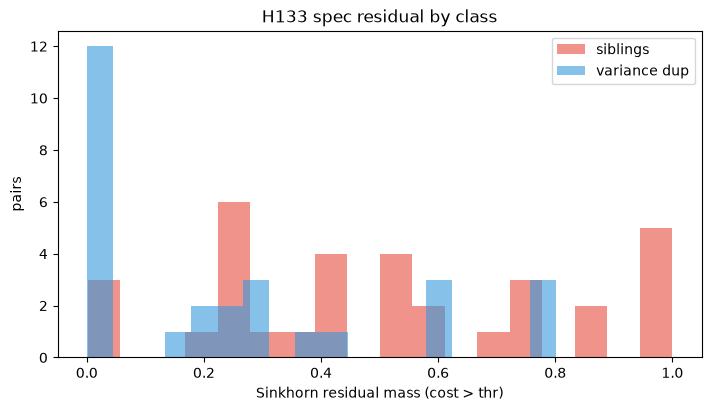

H133 - Sinkhorn spec residual
──────────────────────────────────────────────

pairs (both >=3 spec) : 61 (33 sib / 28 var)

residual AUC          : 0.746

combined (m,r,c) AUC  : 0.701

best precision @rec>=0.5 : 0.741 (recall 0.61)  bar 0.8

verdict : REFUTED

In [7]:
# H133 - restrict to pairs with >= 3 spec items on both sides, within variance vs sibling
h133_pairs = [(p["a"], p["b"], 1 if p["cls"] == "sibling" else 0)  # 1 = sibling (to be flagged)
              for p in pairs if p["cls"] in ("variance", "sibling")
              and p["a"] in E and p["b"] in E
              and len(E[p["a"]]["spec"]) >= 3 and len(E[p["b"]]["spec"]) >= 3]

all_items = set()
for a, b, y in h133_pairs:
    all_items.update(spec_items(a)); all_items.update(spec_items(b))
item_emb = embed_strings(sorted(all_items))

def sinkhorn_split(a, b, reg=SINKHORN_REG, thr=RESID_COST_THR):
    ia, ib = spec_items(a), spec_items(b)
    Va = np.stack([item_emb[x] for x in ia]); Vb = np.stack([item_emb[x] for x in ib])
    M = 1.0 - Va @ Vb.T
    wa = np.full(len(ia), 1.0 / len(ia)); wb = np.full(len(ib), 1.0 / len(ib))
    P = ot.sinkhorn(wa, wb, np.ascontiguousarray(M), reg, numItermax=2000)
    residual = float((P * (M > thr)).sum())
    matched = float((P * (M <= thr)).sum())
    cost = float((P * M).sum())
    return matched, residual, cost

yy, feats, resid = [], [], []
for a, b, y in h133_pairs:
    m, r_, c = sinkhorn_split(a, b)
    yy.append(y); feats.append([m, r_, c]); resid.append(r_)
yy = np.array(yy); feats = np.array(feats); resid = np.array(resid)

auc_resid = roc_auc_score(yy, resid)
clf = LogisticRegression(max_iter=1000)
comb = cross_val_predict(clf, feats, yy, cv=5, method="predict_proba")[:, 1]
auc_comb = roc_auc_score(yy, comb)

# precision clause: threshold the residual, predicted-positive = sibling; best precision at recall >= 0.5
prec, rec, thr = precision_recall_curve(yy, resid)
ok = rec[:-1] >= 0.5
best_prec = float(prec[:-1][ok].max()) if ok.any() else 0.0
rec_at_best = float(rec[:-1][ok][np.argmax(prec[:-1][ok])]) if ok.any() else 0.0
h133 = "CONFIRMED" if best_prec >= BAR_H133_PREC else "REFUTED"

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for lab, mask, c in [("siblings", yy == 1, "#E74C3C"), ("variance dup", yy == 0, "#3498DB")]:
    ax.hist(resid[mask], bins=18, alpha=0.6, label=lab, color=c)
ax.set(xlabel="Sinkhorn residual mass (cost > thr)", ylabel="pairs", title="H133 spec residual by class")
ax.legend(); plt.show()

_l = "─" * 46
rprint(f"[bold cyan]H133 - Sinkhorn spec residual[/bold cyan]\n[dim]{_l}[/dim]")
rprint(f"  pairs (both >=3 spec) : [yellow]{len(yy)}[/yellow] ([red]{int(yy.sum())} sib[/red] / [green]{int((yy==0).sum())} var[/green])")
rprint(f"  residual AUC          : [yellow]{auc_resid:.3f}[/yellow]")
rprint(f"  combined (m,r,c) AUC  : [yellow]{auc_comb:.3f}[/yellow]")
rprint(f"  best precision @rec>=0.5 : [yellow]{best_prec:.3f}[/yellow] (recall {rec_at_best:.2f})  bar {BAR_H133_PREC}")
rprint(f"  verdict : [bold]{h133}[/bold]")

## H137 - Wasserstein barycenter chain guard

For each SAME_AS closure that contains a labeled false merge, the Wasserstein barycenter of member
record-bags (token embeddings, free-support) is the cluster centre of mass. Member-to-barycenter
distance should sit far for the falsely-chained intruders (the accessory / cable / filter leaves
attached by a shared model code or deictic reference). Members are labelled from the forensics
false-merge edges: the non-hub endpoint of a false edge is an intruder.

In [8]:
# Build SAME_AS closures (connected components over the undirected edges)
adj = defaultdict(set)
for r in same_as:
    a, b = r["a"], r["b"]
    if a in E and b in E:
        adj[a].add(b); adj[b].add(a)

seen, comps = set(), []
for n0 in list(adj):
    if n0 in seen:
        continue
    st, comp = [n0], set()
    while st:
        x = st.pop()
        if x in seen:
            continue
        seen.add(x); comp.add(x); st.extend(adj[x] - seen)
    comps.append(comp)

false_edges = [frozenset((p["a"], p["b"])) for p in labeled_fm
               if p["a"] in E and p["b"] in E]
false_names = set()
for fe in false_edges:
    false_names.update(fe)

affected = [c for c in comps if any(fe <= c for fe in false_edges)]
print("closures with a labeled false edge:", len(affected), "sizes", sorted(len(c) for c in affected))

# embed every token that appears in an affected-closure member
member_tokens = set()
for c in affected:
    for m in c:
        member_tokens.update(tokens_of(m))
mtok_emb = embed_strings(sorted(member_tokens))

def member_bag(name):
    ts = tokens_of(name)
    if not ts:
        return None
    return np.stack([mtok_emb[t] for t in ts])

# per-closure: free-support barycenter, member-to-barycenter distance, intruder label
rows_h137 = []
for c in affected:
    members = [m for m in c if member_bag(m) is not None]
    if len(members) < 3:
        continue
    bags = [member_bag(m) for m in members]
    weights = [np.full(len(b), 1.0 / len(b)) for b in bags]
    k = max(3, int(round(np.mean([len(b) for b in bags]))))
    pool = np.concatenate(bags)
    rng = np.random.RandomState(0)
    X0 = pool[rng.choice(len(pool), min(k, len(pool)), replace=False)].astype(np.float64)
    try:
        bary = ot.lp.free_support_barycenter([b.astype(np.float64) for b in bags], weights, X0.copy())
    except Exception as ex:
        print("barycenter failed on size", len(members), ex)
        continue
    bw = np.full(len(bary), 1.0 / len(bary))
    deg = {m: len(adj[m] & c) for m in members}          # hub = highest within-closure degree
    hub = max(deg, key=deg.get)
    intruder = {}
    for fe in false_edges:
        if fe <= c:
            for m in fe:
                if m != hub:
                    intruder[m] = 1
    for m in members:
        Vm = member_bag(m).astype(np.float64); wm = np.full(len(Vm), 1.0 / len(Vm))
        Dm = ot.dist(Vm, bary, metric="sqeuclidean")
        dist = float(ot.emd2(wm, bw, np.ascontiguousarray(Dm)))
        rows_h137.append({"cluster_size": len(members), "hub": hub, "member": m,
                          "dist": dist, "is_intruder": int(intruder.get(m, 0)),
                          "labeled": int(m in false_names)})

dists = np.array([r["dist"] for r in rows_h137])
labs = np.array([r["is_intruder"] for r in rows_h137])
auc_h137 = roc_auc_score(labs, dists) if 0 < labs.sum() < len(labs) else float("nan")

zero_loss = False
if labs.sum() > 0 and (labs == 0).sum() > 0:
    max_true = dists[labs == 0].max(); min_intruder = dists[labs == 1].min()
    zero_loss = bool(min_intruder > max_true)

h137 = ("CONFIRMED" if (not np.isnan(auc_h137) and auc_h137 >= BAR_H137_AUC and zero_loss)
        else "REFUTED")

_l = "─" * 46
rprint(f"[bold cyan]H137 - barycenter chain guard[/bold cyan]\n[dim]{_l}[/dim]")
rprint(f"  affected closures scored : sizes [yellow]{sorted(set(r['cluster_size'] for r in rows_h137))}[/yellow], {len(rows_h137)} members")
rprint(f"  labeled intruders        : [yellow]{int(labs.sum())}[/yellow] / {len(labs)} members")
rprint(f"  intruder-vs-member AUC   : [yellow]{auc_h137:.3f}[/yellow]  (bar {BAR_H137_AUC})")
rprint(f"  clean threshold (zero true loss) : [yellow]{zero_loss}[/yellow]")
rprint(f"  verdict : [bold]{h137}[/bold]")
for r in sorted(rows_h137, key=lambda x: -x["dist"])[:12]:
    tag = "[red]INTRUDER[/red]" if r["is_intruder"] else "        "
    rprint(f"  {tag} d={r['dist']:.3f}  [dim]{r['member'][:52]}[/dim]")

closures with a labeled false edge: 3 sizes [3, 7, 36]


H137 - barycenter chain guard
──────────────────────────────────────────────

affected closures scored : sizes [3, 7, 36], 46 members

labeled intruders        : 7 / 46 members

intruder-vs-member AUC   : 0.322  (bar 0.85)

...

INTRUDER d=0.476  DreamStation CPAP

d=0.474  CPAP

d=0.461  Auto

d=0.460  Flowmeter

d=0.460  Patient

## Report

In [9]:
stamp = datetime.datetime.now(datetime.timezone.utc).strftime("%Y%m%d-%H%M%S")
out = Path("../reports") / f"transport-r13-records-{stamp}.json"
report = {
    "pair_file": Path(pair_file).name,
    "embedder": EMB_MODEL,
    "h132": {"n_task": int(len(ys)), "auc_cosine": float(auc_cos), "auc_wmd": float(auc_wmd),
             "auc_wmd_whiten": float(auc_wmdw), "gap": float(gap), "bar": BAR_H132_GAP,
             "verdict": h132},
    "h133": {"n_pairs": int(len(yy)), "n_sibling": int(yy.sum()), "auc_residual": float(auc_resid),
             "auc_combined": float(auc_comb), "best_precision_at_rec50": float(best_prec),
             "recall_at_best": float(rec_at_best), "bar": BAR_H133_PREC, "verdict": h133},
    "h137": {"affected_sizes": sorted(len(c) for c in affected), "n_members": len(rows_h137),
             "n_intruders": int(labs.sum()), "auc": None if np.isnan(auc_h137) else float(auc_h137),
             "clean_threshold": zero_loss, "bar": BAR_H137_AUC, "verdict": h137,
             "members": rows_h137},
}
out.write_text(json.dumps(report, indent=2, default=str))
rprint("saved", str(out))
rprint(f"[bold]VERDICTS[/bold]  H132 {h132}  H133 {h133}  H137 {h137}")

saved ../reports/transport-r13-records-20260707-090937.json

VERDICTS  H132 REFUTED  H133 REFUTED  H137 REFUTED